In [1]:
!pip uninstall -y pyspark


Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1


In [2]:
!pip install pyspark==3.5.1


  Using cached pyspark-3.5.1-py2.py3-none-any.whl
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [3]:
!apt-get install -y openjdk-11-jdk-headless

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-11-jdk-headless is already the newest version (11.0.30+7-1ubuntu1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 39 not upgraded.


In [4]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ml-bank") \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

spark.range(5).show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [7]:
df = spark.read.csv('/content/bank.csv', header=True, inferSchema=True)
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [8]:
numeric_features = [t[0] for t in df.dtypes if t[1] == 'int']
df.select(numeric_features).describe().toPandas()

,summary,age,balance,day,duration,campaign,pdays,previous
0,count,11162,11162,11162,11162,11162,11162,11162
1,mean,41.231947679627304,1528.5385235620856,15.658036194230425,371.99381831213043,2.508421429851281,51.33040673714388,0.8325568894463358
2,stddev,11.913369192215518,3225.413325946149,8.420739541006462,347.12838571630687,2.7220771816614824,108.75828197197717,2.292007218670508
3,min,18,-6847,1,2,1,-1,0
4,max,95,81204,31,3881,63,854,58


In [9]:
df = df.select('age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit')
cols = df.columns
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [11]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
categoricalColumns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
stages = []
for categoricalCol in categoricalColumns:
    stringIndexer = StringIndexer(inputCol = categoricalCol, outputCol = categoricalCol + 'Index')
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "classVec"])
    stages += [stringIndexer, encoder]
label_stringIdx = StringIndexer(inputCol = 'deposit', outputCol = 'label')
stages += [label_stringIdx]
numericCols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
assemblerInputs = [c + "classVec" for c in categoricalColumns] + numericCols
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

In [12]:
stages

[StringIndexer_84b859efcb1f,
 OneHotEncoder_a6b9c27862c0,
 StringIndexer_e1adfd47b318,
 OneHotEncoder_2f94592980e6,
 StringIndexer_ac243995283d,
 OneHotEncoder_f62fa48c2b3b,
 StringIndexer_075185e26698,
 OneHotEncoder_b02677c96233,
 StringIndexer_50c60d2e107e,
 OneHotEncoder_b5575a7a5a41,
 StringIndexer_c437f6b16499,
 OneHotEncoder_d4f6e848e5a7,
 StringIndexer_e6e8a89d947a,
 OneHotEncoder_667af488c541,
 StringIndexer_4008c0b51d96,
 OneHotEncoder_5e55bb208116,
 StringIndexer_b63957edb091,
 VectorAssembler_e2587e8cb64b]

In [13]:
from pyspark.ml import Pipeline
pipeline = Pipeline(stages = stages)
pipelineModel = pipeline.fit(df)
df = pipelineModel.transform(df)


In [14]:
df.show(2)

+---+------+-------+---------+-------+-------+-------+----+-------+--------+--------+-----+--------+--------+-------+--------+--------------+------------+---------------+--------------+-----------------+------------+---------------+------------+---------------+---------+-------------+------------+---------------+-------------+----------------+-----+--------------------+
|age|   job|marital|education|default|balance|housing|loan|contact|duration|campaign|pdays|previous|poutcome|deposit|jobIndex|   jobclassVec|maritalIndex|maritalclassVec|educationIndex|educationclassVec|defaultIndex|defaultclassVec|housingIndex|housingclassVec|loanIndex| loanclassVec|contactIndex|contactclassVec|poutcomeIndex|poutcomeclassVec|label|            features|
+---+------+-------+---------+-------+-------+-------+----+-------+--------+--------+-----+--------+--------+-------+--------+--------------+------------+---------------+--------------+-----------------+------------+---------------+------------+---------

In [15]:
selectedCols = ['label', 'features']
df = df.select(selectedCols)

In [16]:
df.show(2)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  1.0|(30,[3,11,13,16,1...|
|  1.0|(30,[3,11,13,16,1...|
+-----+--------------------+
only showing top 2 rows



In [17]:
train, test = df.randomSplit([0.7, 0.3], seed = 2018)
print("Training Dataset Count: " + str(train.count()))
print("Test Dataset Count: " + str(test.count()))

Training Dataset Count: 7855
Test Dataset Count: 3307


In [18]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(featuresCol = 'features', labelCol = 'label', maxIter=10)
lrModel = lr.fit(train)

In [19]:
import matplotlib.pyplot as plt

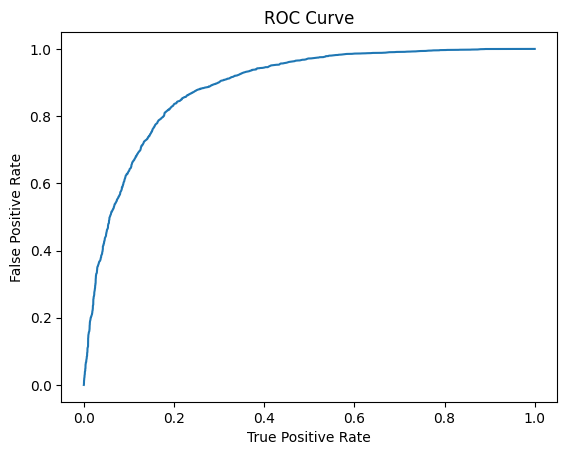

Training set areaUnderROC: 0.8877385690600346


In [20]:
trainingSummary = lrModel.summary
roc = trainingSummary.roc.toPandas()
plt.plot(roc['FPR'],roc['TPR'])
plt.ylabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
print('Training set areaUnderROC: ' + str(trainingSummary.areaUnderROC))

In [21]:
predictions = lrModel.transform(test)
#predictions.select('age', 'job', 'label', 'rawPrediction', 'prediction', 'probability').show(10)

In [22]:
predictions.show()

+-----+--------------------+--------------------+--------------------+----------+
|label|            features|       rawPrediction|         probability|prediction|
+-----+--------------------+--------------------+--------------------+----------+
|  0.0|(30,[0,11,13,16,1...|[1.93084854518128...|[0.87334331124860...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[1.92783695472097...|[0.87300981013433...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[-0.7737627890181...|[0.31566570209267...|       1.0|
|  0.0|(30,[0,11,13,16,1...|[0.94708137344074...|[0.72052784002179...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2.44657764692457...|[0.92031082026376...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[1.28386077546037...|[0.78310624913886...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[1.05745870556531...|[0.74220460119091...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[3.25200815517462...|[0.96274520587479...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2.24978402804239...|[0.90463190417562...|       0.0|
|  0.0|(30,[0,11

In [23]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator()
print('Test Area Under ROC', evaluator.evaluate(predictions))

Test Area Under ROC 0.885643189559481


In [24]:
train.show()

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
+-----+--------------------+
only showing top 20 rows



In [25]:
from pyspark.ml.classification import DecisionTreeClassifier
dt = DecisionTreeClassifier(featuresCol = 'features', labelCol = 'label', maxDepth = 3)
dtModel = dt.fit(train)
predictions = dtModel.transform(test)
predictions.show(20)

+-----+--------------------+--------------+--------------------+----------+
|label|            features| rawPrediction|         probability|prediction|
+-----+--------------------+--------------+--------------------+----------+
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[520.0,1931.0]|[0.21215830273357...|       1.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[

In [26]:
evaluator = BinaryClassificationEvaluator()
print("Test Area Under ROC: " + str(evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})))

Test Area Under ROC: 0.7808118726917547


In [27]:
from pyspark.ml.classification import RandomForestClassifier
rf = RandomForestClassifier(featuresCol = 'features', labelCol = 'label')
rfModel = rf.fit(train)
predictions = rfModel.transform(test)
predictions.show(10)

+-----+--------------------+--------------------+--------------------+----------+
|label|            features|       rawPrediction|         probability|prediction|
+-----+--------------------+--------------------+--------------------+----------+
|  0.0|(30,[0,11,13,16,1...|[14.6977753406763...|[0.73488876703381...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[14.5894414348018...|[0.72947207174009...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[7.43768577160823...|[0.37188428858041...|       1.0|
|  0.0|(30,[0,11,13,16,1...|[13.7749722226654...|[0.68874861113327...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[15.0025343930509...|[0.75012671965254...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[14.4310239407855...|[0.72155119703927...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[14.2904547721679...|[0.71452273860839...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[16.6445699090142...|[0.83222849545071...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[16.4376860938430...|[0.82188430469215...|       0.0|
|  0.0|(30,[0,11

In [28]:
evaluator = BinaryClassificationEvaluator()
print("Test Area Under ROC: " + str(evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})))

Test Area Under ROC: 0.8783968366238182


In [29]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator()